In [ ]:
from dotenv import load_dotenv
load_dotenv()

from typing import Annotated
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langgraph.graph.message import add_messages
from deepagents.backends import FilesystemBackend
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, BaseMessage
from deepagents.middleware.filesystem import FilesystemMiddleware

print("✅ 环境准备完成")

✅ 环境准备完成


In [ ]:
model = ChatOpenAI(
    model="deepseek-v4-pro",
    model_kwargs={"extra_body": {"thinking": {"type": "disabled"}}}
)

backend = FilesystemBackend(root_dir='../examples-data', virtual_mode=True)

d:\Documents\GitHub\learn-langchain\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3641: UserWarning: Parameters {'extra_body'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


In [3]:
EDITOR_SYSTEM_PROMPT = """\
你是 Markdown 文档目录结构整理专家。修改 md 文件内容时只能使用 Edit 工具，不管有多少处需要改，禁止用 sed、Python 脚本等任何批量替换方式。

## 提取并比对

提取正文中所有标题的原始结构（如实展示，不自行整理美化），与文档开头的自带 TOC 目录比对，列出问题清单（如：层级错位、未在 TOC 中出现的小标题误用了 #、正文缺失 TOC 中的某级标题等），并给出具体修改建议，然后逐项修改。若文档没有 TOC，则依据合理的标题层级逻辑自行判断并修正。

## 修改规则

**核心校验基准**：正文前若有自带 TOC 目录，以 TOC 的层级结构和编号形式为基准，反向校对并修正正文标题。但 TOC 本身可能有明显错误（如层级跳跃、编号不连续、漏掉明显章节），遇到此类情况应按合理逻辑一并修正 TOC，不要盲从。

- **匹配标题层级**：若有 TOC 则以 TOC 为基准调整，但 TOC 本身有明显错误（层级跳跃、编号不连续等）时应一并修正 TOC；若无 TOC 则确保标题层级逐级递进，不跳跃。
- **降级封面标题**：正文开头的文档封面大标题（如 # XX方案）不是章节，降级为 **加粗**。
- **降级"目录"二字所在行**：正文中字面为「目录」的一行（如 ## 目录）不是章节标题，降级为 **加粗**。
- **补充缺失标题**：TOC 中有但正文未被解析为标题的章节（如仅加粗或遗漏 #），按 TOC 层级手动补充为 # 正文标题。
- **降级非 TOC 小标题**：正文内更细碎的编号（如"一、""1、""（1）"等），若未在 TOC 中出现，一律不用 # 标题，改为 **加粗**。
- **清理格式**：去除残余锚点标记（[]{#_Toc...} 等），# 与标题文字之间保留一个半角空格。

改完重新提取标题树，核对确认所有问题已修正。"""

edit_agent = create_agent(
    model,
    system_prompt=EDITOR_SYSTEM_PROMPT,
    middleware=[FilesystemMiddleware(backend=backend)],
)

In [4]:
AUDITOR_SYSTEM_PROMPT = """\
你是一个 Markdown 文档结构审计员。你的任务是检查经过标题修正后的 Markdown 文件是否完全符合规范。

## 审计规则

逐项检查以下规则，任何一项不通过即为不合格：

1. **标题层级合理**：若有 TOC，正文标题层级应与 TOC 一致，但 TOC 本身有明显错误（层级跳跃、编号不连续等）时，TOC 和正文应已被一并修正而非照搬错误；若无 TOC，标题层级必须逐级递进（# → ## → ###），不允许跳跃。
2. **封面标题降级**：正文开头的文档封面大标题（如 # XX方案）不是章节，必须已降级为 **加粗**。
3. **"目录"行降级**：正文中字面为「目录」的一行（如 ## 目录）不是章节标题，必须已降级为 **加粗**。
4. **非 TOC 小标题降级**：正文内更细碎的编号（如"一、""1、""（1）"等），若未在 TOC 中出现（或无 TOC 时不属于正经章节），必须已改为 **加粗**，而非 # 标题。
5. **锚点清理**：是否已去除所有残余锚点标记（如 {#_Toc...}、[]{#...} 等）？
6. **标题格式**：# 与标题文字之间是否保留了一个半角空格？

如果文件完全符合以上所有规则，请只输出 "PASS"（大写，不要有其他字符）。
如果任何一项不通过，请明确指出：
- 哪条规则未通过
- 具体哪些行有问题
- 应该如何修正

你的反馈将直接交给编辑者进行修正，请确保反馈清晰、具体、可执行。"""

auditor_agent = create_agent(
    model,
    system_prompt=AUDITOR_SYSTEM_PROMPT,
    middleware=[FilesystemMiddleware(backend=backend)],
)

In [ ]:
class AgentState(BaseModel):
    messages: Annotated[list[BaseMessage], add_messages] = Field(
        default_factory=list
    )
    is_valid: bool = False
    attempts: int = 0
    audit_feedback: str = ""


def editor_node(state: AgentState) -> dict:
    """编辑节点：调用 agent 修改 MD 文件"""
    attempts = state.attempts + 1

    input_messages = list(state.messages)

    result = edit_agent.invoke({"messages": input_messages})

    new_messages = result["messages"][len(state.messages) :]

    return {
        "messages": new_messages,
        "attempts": attempts,
    }


def auditor_node(state: AgentState) -> dict:
    """审计节点：调用审计 agent 读取并检查修改后的文件"""
    audit_prompt = HumanMessage(
        content=(
            "请审计刚才编辑过的同一个 Markdown 文件的标题结构是否完全符合规范。"
            "从对话上下文中确认是哪个文件。"
        )
    )
    audit_result = auditor_agent.invoke({"messages": [audit_prompt]})
    audit_feedback = audit_result["messages"][-1].content.strip()

    if audit_feedback.startswith("PASS"):
        return {"is_valid": True, "audit_feedback": audit_feedback}
    else:
        feedback_msg = HumanMessage(
            name="Auditor",
            content=(
                f"你的修改未通过审计。审计员的反馈是：\n{audit_feedback}\n"
                f"请根据反馈修正，确保所有规则通过！"
            ),
        )
        return {
            "is_valid": False,
            "audit_feedback": audit_feedback,
            "messages": [feedback_msg],
        }


def fail_node(state: AgentState) -> dict:
    """失败节点：超过最大重试次数仍未通过审计时抛出异常"""
    raise RuntimeError(
        f"❌ 经过 {state.attempts} 次修改仍未通过审计。\n"
        f"最后一次审计反馈：\n{state.audit_feedback}"
    )


def should_continue(state: AgentState) -> str:
    """路由判断：PASS → END，失败且 <3 次 → 重试，>=3 次 → 抛出异常"""
    if state.is_valid:
        return END
    if state.attempts >= 3:
        return "fail_node"
    return "editor"

In [6]:
builder = StateGraph(AgentState)

builder.add_node("editor", editor_node)
builder.add_node("auditor", auditor_node)
builder.add_node("fail_node", fail_node)

builder.add_edge(START, "editor")
builder.add_edge("editor", "auditor")
builder.add_conditional_edges(
    "auditor",
    should_continue,
    {
        "editor": "editor",
        "fail_node": "fail_node",
        END: END,
    },
)

workflow = builder.compile()

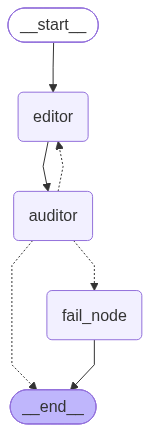

In [7]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [ ]:
task = "修正 /file.md 的标题结构。"

for step in workflow.stream(
    {"messages": [HumanMessage(content=task)]}, stream_mode="values"
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()